In [ ]:
import tensorflow as tf
import numpy as np
import time
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer()

In [33]:
faqs="""
The Machine Learning program is designed to equip students with the theoretical foundations and practical skills needed to develop intelligent systems. By combining computer science, mathematics, and data analysis, the program prepares graduates to solve complex problems across industries such as healthcare, finance, and technology.
Curriculum Highlights
Foundations of Machine Learning: Core concepts including supervised, unsupervised, and reinforcement learning.
Mathematical Foundations: Linear algebra, probability, statistics, and optimization methods.
Programming for ML: Hands-on training in Python, R, and relevant libraries (TensorFlow, PyTorch, Scikit-learn).
Data Science Integration: Data preprocessing, feature engineering, and model evaluation.
Advanced Topics: Deep learning, natural language processing, computer vision, and generative models.
Capstone Project: Real-world application of machine learning techniques to industry-relevant problems.
Once you make the payment
"""

In [ ]:
tokenizer.fit_on_texts(faqs)
print(tokenizer.word_index)
print(tokenizer.texts_to_sequences([faqs]))


{'e': 1, 'n': 2, 'a': 3, 'i': 4, 't': 5, 'r': 6, 'o': 7, 's': 8, 'c': 9, 'l': 10, 'd': 11, 'p': 12, 'm': 13, 'g': 14, 'u': 15, 'h': 16, 'f': 17, 'v': 18, 'y': 19, 'b': 20, 'w': 21, 'k': 22, 'q': 23, 'x': 24, '📚': 25, 'z': 26, 'j': 27}
[[25, 6]]


In [ ]:
input_sequences=[]
for sentences in faqs.split('\n'):
  print(sentences)
  tokenized_sentence=tokenizer.texts_to_sequences([sentences][0])
  for i in range(1,len(tokenized_sentence)):
    input_sequences.append(tokenized_sentence[:i+1])



The Machine Learning program is designed to equip students with the theoretical foundations and practical skills needed to develop intelligent systems. By combining computer science, mathematics, and data analysis, the program prepares graduates to solve complex problems across industries such as healthcare, finance, and technology.
📚 Curriculum Highlights
Foundations of Machine Learning: Core concepts including supervised, unsupervised, and reinforcement learning.
Mathematical Foundations: Linear algebra, probability, statistics, and optimization methods.
Programming for ML: Hands-on training in Python, R, and relevant libraries (TensorFlow, PyTorch, Scikit-learn).
Data Science Integration: Data preprocessing, feature engineering, and model evaluation.
Advanced Topics: Deep learning, natural language processing, computer vision, and generative models.
Capstone Project: Real-world application of machine learning techniques to industry-relevant problems.
Once you make the payment



In [ ]:
tokenizer = Tokenizer()
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Step 2: Fit tokenizer on text
tokenizer.fit_on_texts([faqs])

# Step 3: Convert text to sequence of integers
input_sequences = tokenizer.texts_to_sequences([faqs])
print("Sequences:", input_sequences)
max_len = max(len(seq) for seq in input_sequences)  # longest sequence length
padded_input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

# # Step 4: Pad sequences
x=padded_input_sequences[:,:-1]
y=padded_input_sequences[:,-1]


Sequences: [[3, 5, 2, 8, 14, 15, 4, 16, 17, 18, 3, 19, 6, 1, 20, 21, 22, 4, 23, 24, 25, 26, 27, 9, 10, 28, 1, 7, 29, 3, 8, 30, 31, 4, 32, 33, 11, 34, 35, 36, 37, 38, 39, 1, 40, 41, 42, 43, 6, 12, 5, 2, 44, 45, 46, 47, 48, 1, 49, 2, 50, 6, 51, 52, 53, 54, 1, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 1, 13, 66, 67, 68, 69, 70, 7, 10, 71, 7, 72, 73, 74, 1, 75, 76, 77, 78, 79, 2, 80, 81, 82, 9, 83, 1, 84, 85, 86, 87, 88, 89, 90, 12, 5, 2, 91, 4, 92, 13, 11, 93, 94, 95, 3, 96]]


In [ ]:
max_len=max([len(x) for x in input_sequences])

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_len = max(len(seq) for seq in input_sequences)  # longest sequence length
padded_input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')
# padded_input_sequences



In [ ]:
from tensorflow.keras.utils import to_categorical
y=to_categorical(y,num_classes=len(tokenizer.word_index)+1)
y.shape

(1, 97)

In [ ]:
## LSTM Begins here

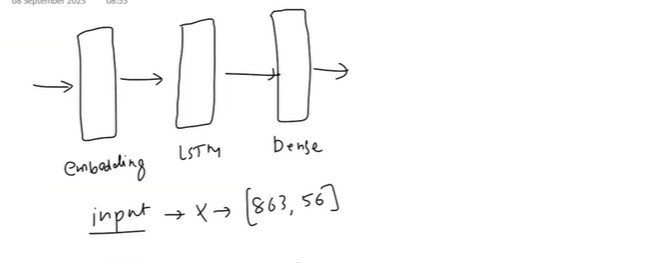

In [ ]:
Image.open(r'/content/lstm_architecture.jpg')

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Embedding,Dense

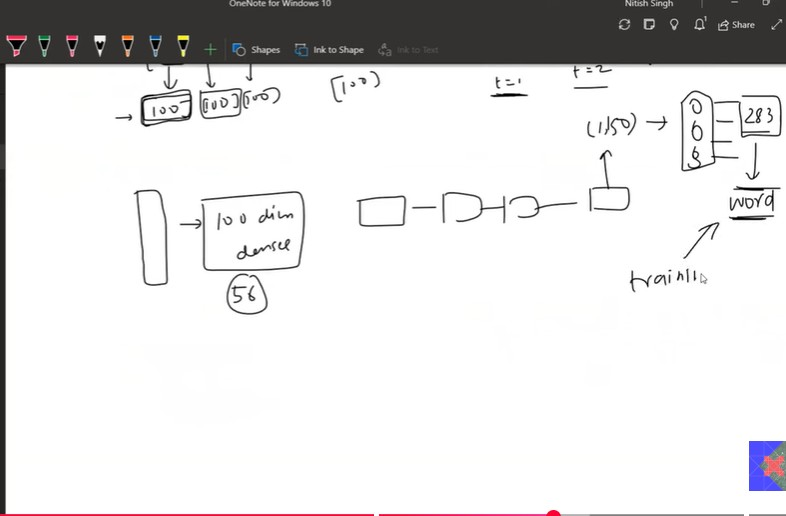

In [ ]:
from PIL import Image
Image.open(r'/content/arch_lstm.jpg')

In [ ]:
num_classes = y.shape[1]   # should be 93
model = Sequential()
model.add(Embedding(283, 100, input_length=56))  # 283 is vocab size
model.add(LSTM(150))
model.add(Dense(num_classes, activation='softmax'))  # <-- use 93 here
model.compile(loss='categorical_crossentropy', optimizer='Adam')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(x,y,epochs=10)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 4.5657
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 4.5215
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - loss: 4.4743
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 4.4181
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 4.3449
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 4.2407
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 4.0732
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 3.7419
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - loss: 2.7930
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 1.2245


In [ ]:
text = "designed payment"
reverse_word_index = {index: word for word, index in tokenizer.word_index.items()}

for i in range(10):  # generate 10 words
    token_text = tokenizer.texts_to_sequences([text])[0]
    pad_token_input = pad_sequences([token_text], maxlen=56)

    prediction = model.predict(pad_token_input)
    pos = np.argmax(prediction[0])   # or use sampling

    word = reverse_word_index.get(pos, "")
    text += " " + word
    print(text)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
designed payment payment
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
designed payment payment payment
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
designed payment payment payment payment
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
designed payment payment payment payment payment
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
designed payment payment payment payment payment payment
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
designed payment payment payment payment payment payment payment
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
designed payment payment payment payment payment payment payment payment
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
designed payment payment payment payment payment payment payment payment payment
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
designed payment payment payment payment payment payment payment payment payment payment
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
designed payment payment payment payment payment payment payment payment payment payment payment


In [ ]:
import numpy as np

def sample_with_temperature(preds, temperature=1.0):
    preds = np.asarray(preds).astype("float64")
    preds = np.log(preds + 1e-8) / temperature
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    return np.random.choice(len(preds), p=preds)

pos = sample_with_temperature(prediction[0], temperature=0.8)
word = reverse_word_index.get(pos, "")

In [34]:
text = "designed payment"
reverse_word_index = {index: word for word, index in tokenizer.word_index.items()}

for i in range(29):  # generate 10 words
    token_text = tokenizer.texts_to_sequences([text])[0]
    pad_token_input = pad_sequences([token_text], maxlen=56)

    prediction = model.predict(pad_token_input)
    pos = sample_with_temperature(prediction[0], temperature=0.8)

    word = reverse_word_index.get(pos, "")
    if word and word != text.split()[-1]:
        text += " " + word
    print(text)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
designed payment
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
designed payment project
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
designed payment project payment
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
designed payment project payment
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
designed payment project payment
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
designed payment project payment
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
designed payment project payment algebra
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
designed payment project payment algebra payment
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
designed payment project payment algebra payment
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
designed payment project payment algebra payment for
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
designed payment project payment algebra payment for
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
designed payment project payment algebra payment for payment
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
designed payment project p